### 1. scRNA-Seqの前処理
- データセット: GSE129516
    - Landscape of intercellular crosstalk in fatty liver disease revealed by single-cell secretome analysis (Cell, 2019)
    - Mouse NASH Liver
- 内容
    - n=3のサンプルの統合
    - 前処理
    - クラスタリングと細胞アノテーション
    

In [1]:
DATA_DIR = '/workspace/cluster/HDD/azuma/Azuma_ISN/datasource/scRNASeq/GSE129516'

import numpy as np
import pandas as pd
import scanpy as sc
import anndata as ad

from tqdm import tqdm

***
#### 各サンプルを統合

In [2]:
# %% Load each data and concatenate

mat_paths = [f'{DATA_DIR}/mtx/GSM3714750_nash1_filtered_gene_bc_matrices.csv',
             f'{DATA_DIR}/mtx/GSM3714751_nash2_filtered_gene_bc_matrices.csv',
             f'{DATA_DIR}/mtx/GSM3714752_nash3_filtered_gene_bc_matrices.csv']

adatas = {}
for sub_id in tqdm(range(len(mat_paths))):
    tmp_df = pd.read_csv(mat_paths[sub_id],index_col=0)
    tmp_adata = ad.AnnData(np.array(tmp_df, dtype=float)).transpose() 
    tmp_adata.obs_names = tmp_df.columns.tolist()  # add barcode info

    adatas[sub_id] = tmp_adata
adata = ad.concat(adatas, label="sample", axis=0)  # n_obs × n_vars = n_sample x n_gene
adata.var_names = tmp_df.index.tolist()  # add gene list
adata.var_names_make_unique()

100%|██████████| 3/3 [02:26<00:00, 48.88s/it]
/opt/250102_test_env/lib/python3.11/site-packages/anndata/_core/anndata.py:1756: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


***
#### Quality Check
- ミトコンドリア遺伝子の排除
- リボソーム遺伝子の排除
- この辺りの作法は[issue #5](https://github.com/mizuno-group/omics-util/issues/5)のシングルセルデータ解析も参考になるかも

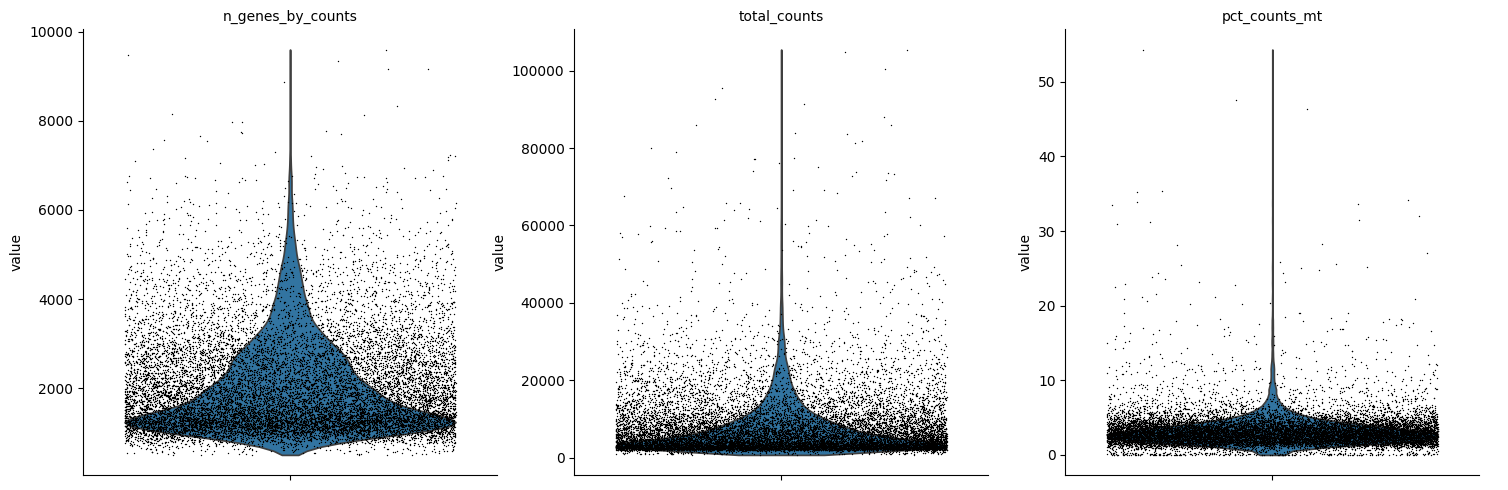

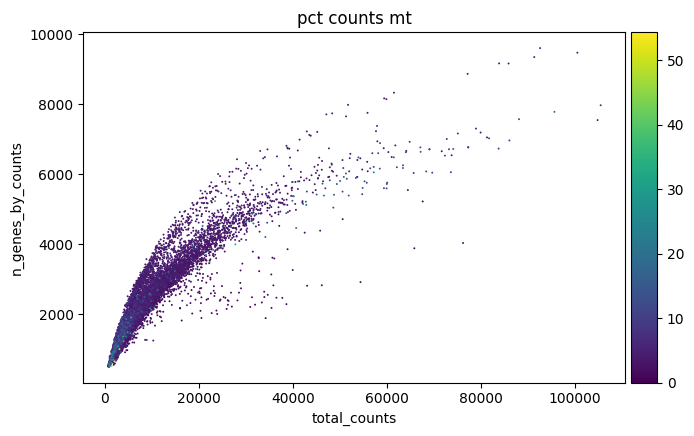

/opt/250102_test_env/lib/python3.11/site-packages/scanpy/preprocessing/_simple.py:176: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs["n_genes"] = number
/opt/250102_test_env/lib/python3.11/site-packages/anndata/_core/anndata.py:1756: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/opt/250102_test_env/lib/python3.11/site-packages/anndata/_core/anndata.py:1756: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/opt/250102_test_env/lib/python3.11/site-packages/anndata/_core/anndata.py:1756: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


In [3]:
adata.var["mt"] = adata.var_names.str.startswith("mt-")
adata.var["ribo"] = adata.var_names.str.startswith(("Rps", "Rpl"))
sc.pp.calculate_qc_metrics(
    adata, qc_vars=["mt", "ribo"], inplace=True, log1p=True
)

sc.pl.violin(
    adata,
    ["n_genes_by_counts", "total_counts", "pct_counts_mt"],
    jitter=0.4,
    multi_panel=True,
)
sc.pl.scatter(adata, "total_counts", "n_genes_by_counts", color="pct_counts_mt")

# Filterting according to mitchondrial genes
adata.obs['percent_mito'] = np.sum(adata[:, adata.var["mt"]].X, axis=1) / np.sum(adata.X, axis=1)
adata = adata[adata.obs['percent_mito'] < 0.10, :]  # 0.05 (doi.org/10.1186/s12967-022-03675-2)

# Filtering
sc.pp.filter_cells(adata, min_genes=100)  # less than 100 genes expressed
sc.pp.filter_genes(adata, min_cells=3)  # genes that aredetected in less than 3 cells


***
#### 加工
- 対数変換
- 高分散遺伝子選択
- バッチ補正

/tmp/ipykernel_1699923/715126993.py:5: FutureWarning: Use sc.pp.normalize_total instead
  sc.pp.normalize_per_cell(adata, counts_per_cell_after=1e4)
/opt/250102_test_env/lib/python3.11/site-packages/anndata/_core/anndata.py:1756: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/opt/250102_test_env/lib/python3.11/site-packages/scanpy/preprocessing/_simple.py:591: FutureWarning: Use sc.pp.normalize_total instead
  normalize_per_cell(


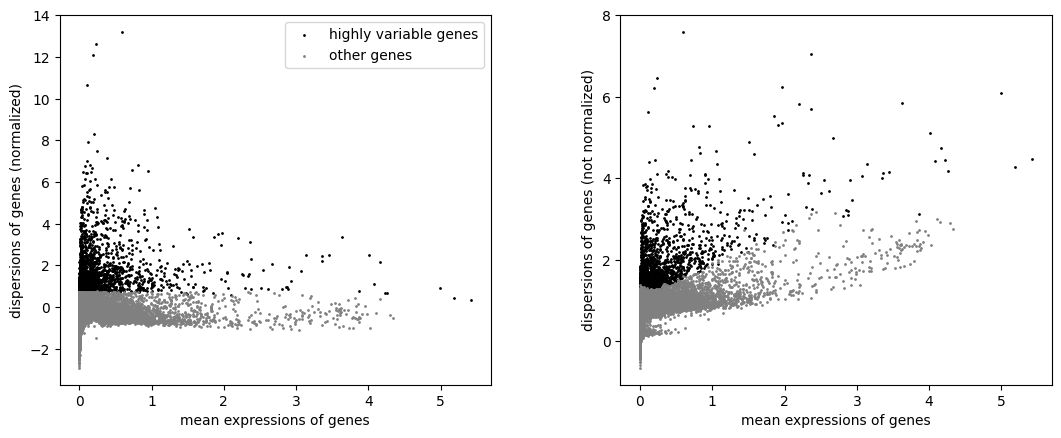

/opt/250102_test_env/lib/python3.11/site-packages/scanpy/preprocessing/_combat.py:343: RuntimeWarning: divide by zero encountered in divide
  (abs(g_new - g_old) / g_old).max(), (abs(d_new - d_old) / d_old).max()


In [4]:
# %% Batch normalization (combat)
adata.layers["counts"] = adata.X.copy()

#normalize and log-transform
sc.pp.normalize_per_cell(adata, counts_per_cell_after=1e4)
sc.pp.log1p(adata)

# feature selection
sc.pp.highly_variable_genes(adata, n_top_genes=2000, batch_key="sample")
sc.pl.highly_variable_genes(adata)

# first store the raw data 
adata.raw = adata

# run combat
sc.pp.combat(adata, key='sample')

***
#### 可視化

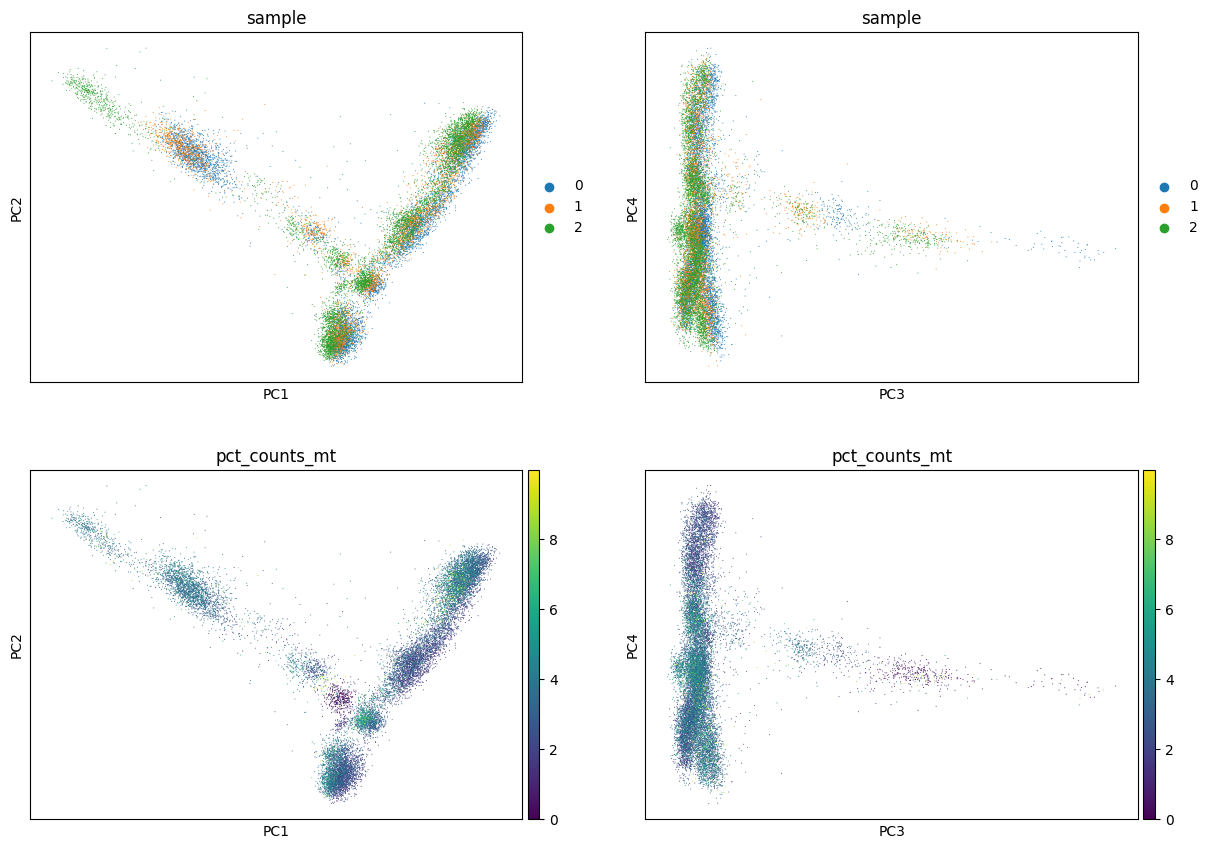

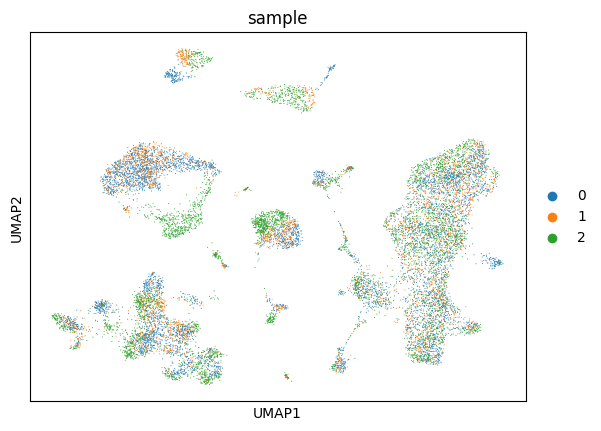

/tmp/ipykernel_1699923/2489099358.py:21: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(adata, n_iterations=2)


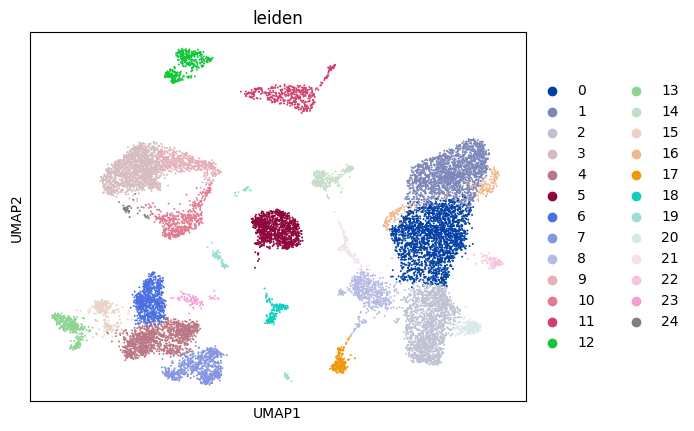

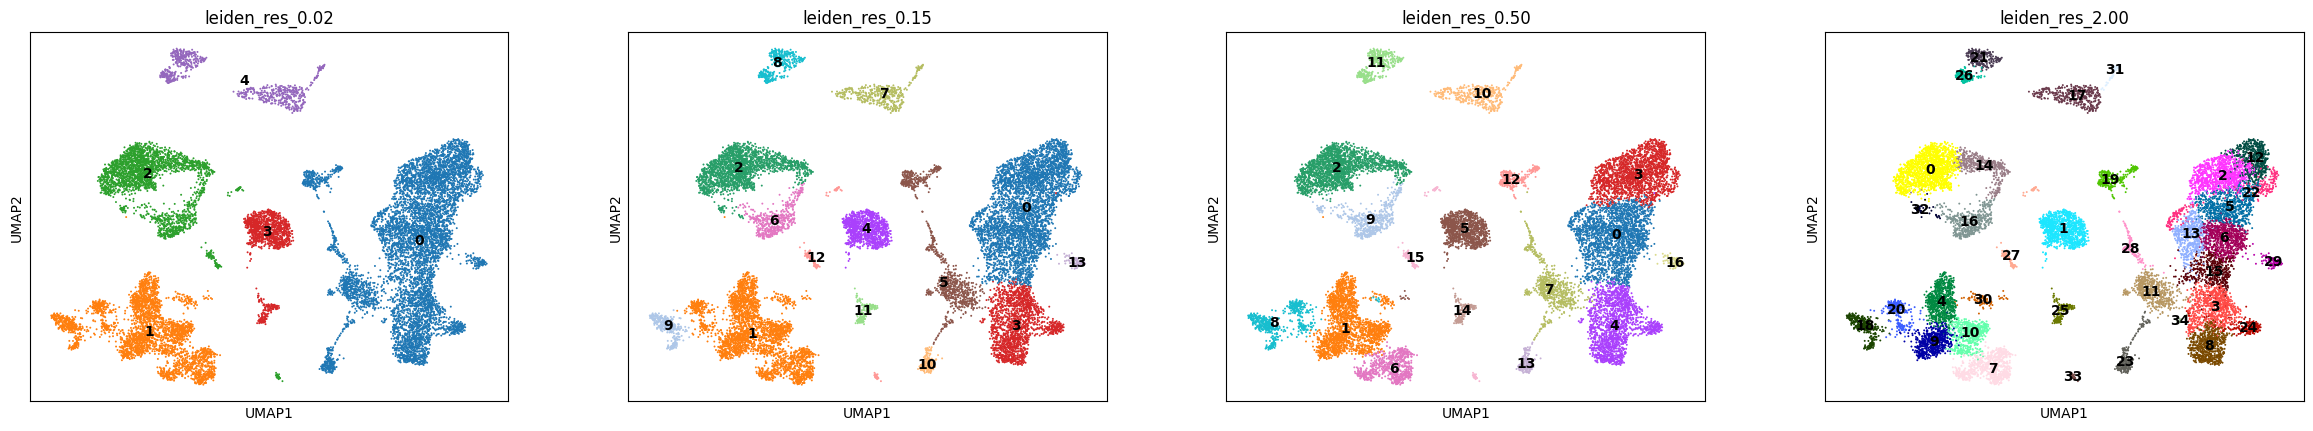

In [5]:
# %% PCA and UMAP
sc.tl.pca(adata)
sc.pl.pca(
    adata,
    color=["sample", "sample", "pct_counts_mt", "pct_counts_mt"],
    dimensions=[(0, 1), (2, 3), (0, 1), (2, 3)],
    ncols=2,
    size=2,
)

sc.pp.neighbors(adata)
sc.tl.umap(adata)
sc.pl.umap(
    adata,
    color="sample",
    # Setting a smaller point size to get prevent overlap
    size=2,
)

# Clustering
sc.tl.leiden(adata, n_iterations=2)
sc.pl.umap(adata, color=["leiden"])

# Annotation with marker genes
for res in [0.02, 0.15, 0.50, 2.00]:
    sc.tl.leiden(
        adata, key_added=f"leiden_res_{res:4.2f}", resolution=res
    )
sc.pl.umap(
    adata,
    color=["leiden_res_0.02", "leiden_res_0.15", "leiden_res_0.50", "leiden_res_2.00"],
    legend_loc="on data",
)


***
#### 細胞種アノテーション
- マーカー遺伝子の発現量を目視で確認して、マニュアルでアノテーションしているが、さすがにもう少し賢くできると思う
- 自動化のオプションもあったと思うので確認しても良いかも

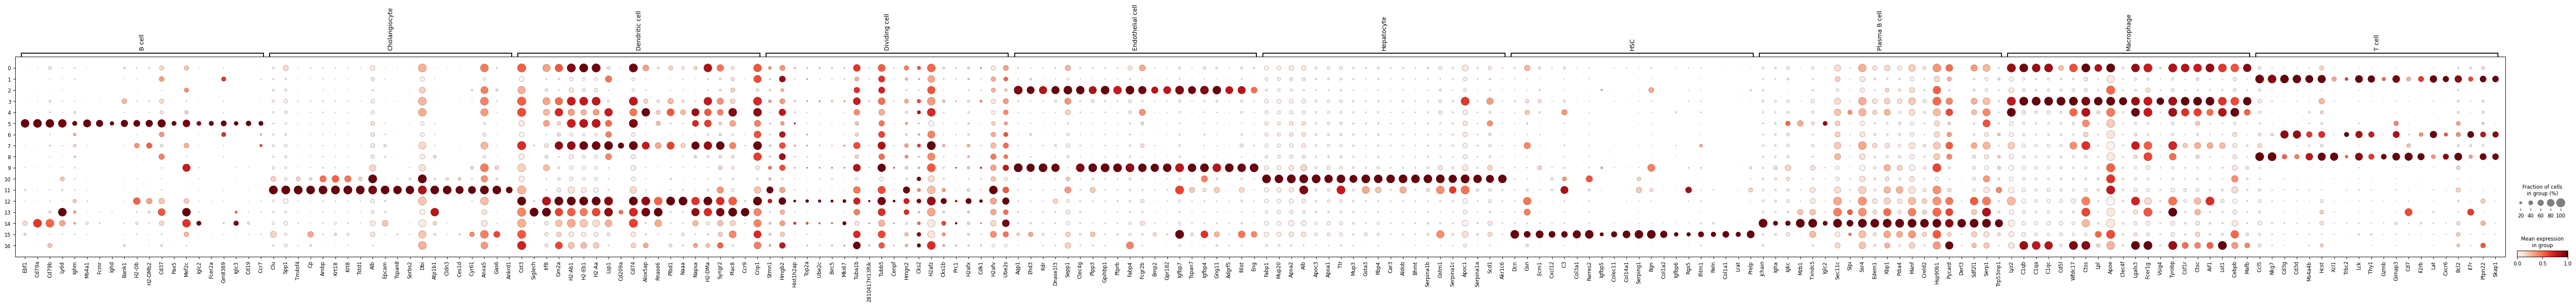

In [6]:
# %% Annotation with maker genes
# prepare dict contains marker gene names
info_df = pd.read_csv(f'{DATA_DIR}/info/TableS2.csv')
cell_list = info_df['cell type'].unique().tolist()
threshold = 2.5
top_n = 20
marker_list = []
for cell in cell_list:
    tmp_info = info_df[info_df['cell type']==cell]
    tmp_info = tmp_info.sort_values("Seurat_log2FC",ascending=False)
    #marker = tmp_info[tmp_info["Seurat_log2FC"]>threshold]["gene_symbol"].tolist()
    marker = tmp_info["gene_symbol"].tolist()[0:top_n]
    marker_list.append(marker)
marker_dict = dict(zip(cell_list,marker_list))

sc.pl.dotplot(adata, marker_dict, groupby="leiden_res_0.50", standard_scale="var")

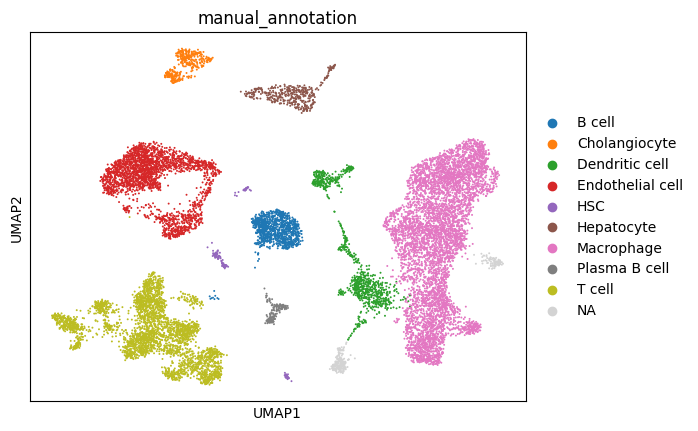

In [8]:
adata.obs["manual_annotation"] = adata.obs["leiden_res_0.50"].map(
    {
        "0": "Macrophage",
        "1": "T cell",
        "2": "Endothelial cell",
        "3": "Macrophage",
        "4": "Macrophage",
        "5": "B cell",
        "6": "T cell",
        "7": "Dendritic cell",
        "8": "T cell",
        "9": "Endothelial cell",
        "10": "Hepatocyte",
        "11": "Cholangiocyte",
        "12": "Dendritic cell",
        "14": "Plasma B cell",
        "15": "HSC",
    }
)
sc.pl.umap(adata, color=["manual_annotation"])

***
#### 保存

In [9]:
# %%
final_adata = adata[adata.obs['manual_annotation'].notna(), :] 
final_adata.write(f'{DATA_DIR}/processed/gse129516_manual_ann.h5ad')